# Cross-Modal Diagnostic Observability — Stage T2-G

## Predictive observability hierarchy and evidence-budget forecasting development kill test v0.1

This notebook performs the complete development-only predictive extension in one run:

- recomputes frozen RA-CB target-performance prediction;
- tests whether an 8-group pilot forecasts the evidence-budget order;
- tests whether outcome-free diagnostics predict final estimator hardness;
- tests whether outcome-free diagnostics predict covariate-balance benefit;
- freezes every success and failure at the **target-dataset** level.

**It does not load, inspect, download or score any locked-blind asset or outcome.**  
Run in a clean Colab CPU runtime using **Runtime → Run all**.


In [13]:
# @title T2-G-0. Mount Drive, verify immutable parents, documents and blind firewall
import hashlib, itertools, json, math, os, platform, sys, warnings
from datetime import datetime, timezone
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
try:
    from IPython.display import display
except Exception:
    display = print

IN_COLAB = False
try:
    from google.colab import drive
    drive.mount("/content/drive")
    IN_COLAB = True
except Exception:
    pass

DEFAULT_ROOT = Path("/content/drive/MyDrive/Cross-Modal_Diagnostic_Observability") if IN_COLAB else Path.cwd()
PROJECT_ROOT = Path(os.environ.get("CDO_PROJECT_ROOT", str(DEFAULT_ROOT)))
CODE_ROOT = PROJECT_ROOT / "05_Code" / "Cross_Modal"
CM_ROOT = PROJECT_ROOT / "06_Data_Records" / "Cross_Modal"
RESULT_ROOT = CM_ROOT / "StageT2-G_Development_Only_Predictive_Observability_Hierarchy_And_Budget_Forecasting_v0.1"
P0, P1, P2, P3, P4 = [RESULT_ROOT / x for x in [
    "00_Protocol", "01_Predictive_Features", "02_Target_Heldout_Predictions",
    "03_Gates_And_Certificates", "04_Results"
]]
for p in [CODE_ROOT, P0, P1, P2, P3, P4]:
    p.mkdir(parents=True, exist_ok=True)

NOTEBOOK_NAME = "CrossModal_StageT2-G_Development_Only_Predictive_Observability_Hierarchy_And_Budget_Forecasting_v0.1.ipynb"
NOTEBOOK_PATH = CODE_ROOT / NOTEBOOK_NAME
THEORY_NAME = "Directed_Diagnostic_Evidence_Transport_Predictive_Observability_Hierarchy_Theory_v0.7.md"
METHOD_NAME = "Predictive_Diagnostic_Observability_Layer_Method_v0.1.md"
PREREG_NAME = "StageT2-G_Predictive_Observability_Hierarchy_Development_Kill_Test_Preregistration_v1.0.md"
THEORY_PATH = PROJECT_ROOT / "03_Theory" / "Directed_Diagnostic_Evidence_Transport_v0.7" / THEORY_NAME
METHOD_PATH = PROJECT_ROOT / "03_Theory" / "Directed_Diagnostic_Evidence_Transport_v0.7" / METHOD_NAME
PREREG_PATH = PROJECT_ROOT / "04_Study_Design" / PREREG_NAME

T2D_ROOT = CM_ROOT / "StageT2-D_Development_Only_AMW-DDET_Active_Minimal_Witness_Certificate_v0.1"
T2D_REPS = T2D_ROOT / "01_Replicate_Results" / "StageT2-D_All_Acquisition_Replicates_v0.1.csv"
T2F_ROOT = CM_ROOT / "StageT2-F_Development_Only_RA-CB-AMW-DDET_Risk_Adaptive_Covariate_Balance_And_Blind_Refreeze_v0.1"
T2F_REPS = T2F_ROOT / "01_RA_CB_Replicates" / "StageT2-F_RA-CB_All_Replicates_v0.1.csv"
T2F_DIAG = T2F_ROOT / "02_Mechanism_And_Applicability" / "StageT2-F_Selector_And_Balance_Diagnostics_v0.1.csv"
T2F_TARGET = T2F_ROOT / "02_Mechanism_And_Applicability" / "StageT2-F_Selector_Target_Summary_v0.1.csv"
T2F_FINAL = T2F_ROOT / "04_Results" / "StageT2-F_Complete_v0.1.json"
T3PF_ACTIVATION = CM_ROOT / "StageT3-PF_Outcome-Free_Preregistration_And_Asset_Preflight_v1.0" / "04_Results" / "StageT3-PF_Activation_Record_v1.0.json"

EXPECTED_SHA = {
    "theory": "a13f27c71e3e46df98d9801b223310be01a82e9f18ebb892be840062249c5a4a",
    "method": "6308e87177315e627dfbcc7df9be6b59243ea0bae45b3b0257c5fd6c81dc7e0c",
    "prereg": "f70675f26f068aa3f9ba3ceaa2a4c0032fb2e7617a9950b4124666607b22186c",
    "t2d_reps": "c6f740510c520167c2ecfbfc48fc2db88428e17ce1b96e6ad5826e507929aedb",
    "t2f_reps": "0ec3b908c0e22d9f713dea2014f3fcdc0d9d8f65b5f86a9be0761ce5da770a79",
    "t2f_diag": "bb4b8a9e9e8c80c2ce1d8d17400bbe645c99ff306f38abca06d57cd514e22f70",
    "t2f_target": "a2228bce855e717bde9078bfec6d75f36cb325734bad99b0f58df0531fa30929",
    "t2f_final": "5fa777822cbe28540f8f1b78ea0c96c4dbc4d6213212ce61558f6d662bca19c4",
    "t3pf_activation": "10646d771a3cd9e86c8c96eb4a134d4878c7542bb4b0b07ab9e01fa8b0c09c25",
}
EXPECTED_T2F_RECORD = "a7dc616c2cf46c772bcd452a7f5804c77f67eae553214217f7525ce59ea6c7e9"
EXPECTED_T3PF_RECORD = "4397cee7798f684159ed77aa5e1edd7b7ae0a24378047d6c89b37ef9ef738a52"

def now():
    return datetime.now(timezone.utc).isoformat()

def sha_file(path):
    h = hashlib.sha256()
    with Path(path).open("rb") as f:
        for block in iter(lambda: f.read(1024 * 1024), b""):
            h.update(block)
    return h.hexdigest()

def sha_json(value):
    return hashlib.sha256(json.dumps(value, sort_keys=True, separators=(",", ":"), ensure_ascii=False).encode()).hexdigest()

def canonical_csv(frame):
    return frame.fillna("").to_csv(index=False, lineterminator="\n", float_format="%.12g")

def write_once(path, text):
    path = Path(path)
    if path.exists():
        assert path.read_text(encoding="utf-8") == text, f"Replay conflict: {path}"
    else:
        path.write_text(text, encoding="utf-8")

def write_csv_once(path, frame):
    write_once(path, canonical_csv(frame))

def write_json_once(path, value):
    write_once(path, json.dumps(value, indent=2, ensure_ascii=False) + "\n")

def verify_self(path, field):
    value = json.loads(Path(path).read_text(encoding="utf-8"))
    claim = value[field]
    core = dict(value)
    core.pop(field)
    assert sha_json(core) == claim, f"Self-hash mismatch: {path}"
    return value

def notebook_source_sha(path):
    value = json.loads(Path(path).read_text(encoding="utf-8"))
    cells = []
    for cell in value.get("cells", []):
        if cell.get("cell_type") not in {"code", "markdown"}:
            continue
        source = cell.get("source", [])
        source = "".join(source) if isinstance(source, list) else str(source)
        cells.append({"cell_type": cell["cell_type"], "source": source.replace("\r\n", "\n")})
    return sha_json(cells)

def seal(path, payload, hash_field="seal_sha256"):
    path = Path(path)
    if path.exists():
        old = verify_self(path, hash_field)
        for k, v in payload.items():
            assert old[k] == v, f"Sealed field changed: {k}"
        return old
    value = dict(payload)
    value["sealed_utc"] = now()
    value[hash_field] = sha_json(value)
    write_json_once(path, value)
    return value

required = [NOTEBOOK_PATH, THEORY_PATH, METHOD_PATH, PREREG_PATH, T2D_REPS, T2F_REPS, T2F_DIAG, T2F_TARGET, T2F_FINAL, T3PF_ACTIVATION]
missing = [str(p) for p in required if not p.is_file()]
assert not missing, "Missing immutable files:\n" + "\n".join(missing)

for role, path in {
    "theory": THEORY_PATH, "method": METHOD_PATH, "prereg": PREREG_PATH,
    "t2d_reps": T2D_REPS, "t2f_reps": T2F_REPS, "t2f_diag": T2F_DIAG,
    "t2f_target": T2F_TARGET, "t2f_final": T2F_FINAL, "t3pf_activation": T3PF_ACTIVATION,
}.items():
    observed = sha_file(path)
    assert observed == EXPECTED_SHA[role], f"Hash mismatch: {role} {observed}"

t2f_final = verify_self(T2F_FINAL, "final_record_sha256")
assert t2f_final["final_record_sha256"] == EXPECTED_T2F_RECORD
assert t2f_final["frozen_gates_passed"] == t2f_final["frozen_gates_total"] == 12
assert t2f_final["locked_blind_assets_touched"] is False
assert t2f_final["stage12_authorised"] is False

t3pf = verify_self(T3PF_ACTIVATION, "activation_record_sha256")
assert t3pf["activation_record_sha256"] == EXPECTED_T3PF_RECORD
assert t3pf["blind_assets_acquired"] is False
assert t3pf["blind_outcomes_accessed"] is False
assert t3pf["outcome_scoring_authorised"] is False
assert t3pf["stage12_authorised"] is False

protocol = seal(P0 / "StageT2-G_Protocol_Seal_v0.1.json", {
    "stage": "StageT2-G",
    "purpose": "development_only_predictive_observability_hierarchy_kill_test",
    "parent_t2f_record": EXPECTED_T2F_RECORD,
    "parent_t3pf_record": EXPECTED_T3PF_RECORD,
    "theory_sha256": EXPECTED_SHA["theory"],
    "method_sha256": EXPECTED_SHA["method"],
    "preregistration_sha256": EXPECTED_SHA["prereg"],
    "notebook_source_sha256": notebook_source_sha(NOTEBOOK_PATH),
    "blind_assets_touched": False,
    "blind_outcomes_accessed": False,
    "stage12_authorised": False,
}, "protocol_seal_sha256")

print("T2-G protocol:", protocol["protocol_seal_sha256"])
print("Blind assets touched:", False)
print("Blind outcomes accessed:", False)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
T2-G protocol: dadd94fc704c0a2c5bb6e21bc4673ea9f987b565136012019cbcec701ba1ee70
Blind assets touched: False
Blind outcomes accessed: False


In [14]:
# @title T2-G-1. Construct frozen performance, pilot-disagreement, hardness and repair targets
t2d = pd.read_csv(T2D_REPS)
t2f = pd.read_csv(T2F_REPS)
diag = pd.read_csv(T2F_DIAG)
target_summary_parent = pd.read_csv(T2F_TARGET)

assert set(t2d["budget"].unique()) == {8, 16, 32, 64, 128}
assert set(t2f["method"].unique()) >= {"amw_u_recomputed", "amw_cb2", "ra_cb_amw_ddet"}
assert t2f["target"].nunique() == 13
assert t2f["edge_id"].nunique() == 27
assert not any(str(x).upper().startswith("BLIND::") for x in t2f["edge_id"].unique())

# Task A: frozen RA-CB performance prediction
ra = t2f[t2f["method"] == "ra_cb_amw_ddet"].copy()
edge_perf = ra.groupby(["target", "modality", "source", "edge_id"], as_index=False).agg(
    true_auc=("true_auc", "first"),
    predicted_auc=("estimate_auc", "median"),
    absolute_error=("absolute_error", "median"),
)
target_perf = edge_perf.groupby(["target", "modality"], as_index=False).agg(
    target_median_error=("absolute_error", "median"),
    edges=("edge_id", "nunique"),
)
performance_median_mae = float(target_perf["target_median_error"].median())
performance_rank = float(spearmanr(edge_perf["true_auc"], edge_perf["predicted_auc"]).statistic)

# Task B outcome: minimum observed AMW budget reaching target median error <= 0.04
amw_curve = (
    t2d[t2d["method"] == "amw_ddet"]
    .groupby(["target", "modality", "budget"], as_index=False)
    .agg(median_error=("absolute_error", "median"))
)
budget_grid = [8, 16, 32, 64, 128]
budget_rows = []
for (target, modality), g in amw_curve.groupby(["target", "modality"]):
    found = None
    for budget in budget_grid:
        row = g[g["budget"] == budget]
        if len(row) and float(row["median_error"].iloc[0]) <= 0.04:
            found = budget
            break
    min_budget = found if found is not None else 256
    budget_rows.append({
        "target": target, "modality": modality,
        "minimum_budget_operational": min_budget,
        "log2_minimum_budget": math.log2(min_budget),
        "right_censored_above_128": found is None,
    })
budget_target = pd.DataFrame(budget_rows)

# Budget-8 pilot disagreement index: legal-method disagreement, target expected-pilot summary
b8 = t2d[t2d["budget"] == 8].copy()
pilot_edge = (
    b8.pivot_table(
        index=["target", "modality", "replicate", "edge_id"],
        columns="method", values="estimate_auc"
    ).reset_index()
)
legal_methods = ["random_direct", "random_logistic_plugin", "random_joint_gmm", "active_direct", "amw_ddet"]
assert all(m in pilot_edge.columns for m in legal_methods)
pilot_edge["cross_method_sd"] = pilot_edge[legal_methods].std(axis=1)
pilot_rep = pilot_edge.groupby(["target", "modality", "replicate"], as_index=False).agg(
    pilot_disagreement=("cross_method_sd", "mean")
)
pilot_target = pilot_rep.groupby(["target", "modality"], as_index=False).agg(
    pilot_disagreement_index=("pilot_disagreement", "median"),
    pilot_disagreement_iqr=("pilot_disagreement", lambda x: float(np.quantile(x, .75) - np.quantile(x, .25))),
)
budget_data = budget_target.merge(pilot_target, on=["target", "modality"], how="inner")
assert len(budget_data) == 13

# Task C/D target-level outcome-free diagnostics
diag_target = diag.groupby(["target", "modality"], as_index=False).agg(
    cv_brier_u=("cv_brier_amw_u", "median"),
    brier_difference_cb2_minus_u=("cv_brier_difference_cb2_minus_u", "median"),
    weight_ess=("weight_ess", "median"),
    balance_residual=("balance_residual_max_standardized", "median"),
    soft_selector_weight=("soft_selector_weight", "median"),
    cb_admissible_rate=("cb_admissible", "mean"),
)

est_pivot = t2f.pivot_table(
    index=["target", "modality", "replicate", "edge_id"],
    columns="method", values="estimate_auc"
).reset_index()
est_pivot["u_cb_disagreement"] = (est_pivot["amw_u_recomputed"] - est_pivot["amw_cb2"]).abs()
disagreement_target = est_pivot.groupby(["target", "modality"], as_index=False).agg(
    u_cb_disagreement=("u_cb_disagreement", "median")
)

u_target = (
    t2f[t2f["method"] == "amw_u_recomputed"]
    .groupby(["target", "modality"], as_index=False)
    .agg(u_error=("absolute_error", "median"))
)
cb_target = (
    t2f[t2f["method"] == "amw_cb2"]
    .groupby(["target", "modality"], as_index=False)
    .agg(cb_error=("absolute_error", "median"))
)
meta_data = (
    diag_target.merge(disagreement_target, on=["target", "modality"])
    .merge(target_perf[["target", "modality", "target_median_error"]], on=["target", "modality"])
    .merge(u_target, on=["target", "modality"])
    .merge(cb_target, on=["target", "modality"])
)
meta_data["repair_gain"] = meta_data["u_error"] - meta_data["cb_error"]
assert len(meta_data) == 13

write_csv_once(P1 / "StageT2-G_Edge_Performance_Predictions_v0.1.csv", edge_perf)
write_csv_once(P1 / "StageT2-G_Target_Performance_Summary_v0.1.csv", target_perf)
write_csv_once(P1 / "StageT2-G_Target_Budget_Complexity_v0.1.csv", budget_data)
write_csv_once(P1 / "StageT2-G_Target_Outcome_Free_Meta_Features_v0.1.csv", meta_data)

display(target_perf)
display(budget_data.sort_values("minimum_budget_operational"))
print("Performance target-level median MAE:", performance_median_mae)
print("Performance edge rank Spearman:", performance_rank)


,target,modality,target_median_error,edges
0,APTOS_2019,retinal_fundus,0.050530,2
1,BUSI_WHU_2025_V3,breast_ultrasound,0.088345,2
2,BUS_BRA_2024,breast_ultrasound,0.016278,2
3,DeepDRiD,retinal_fundus,0.016531,2
4,EyePACS_2015,retinal_fundus,0.019360,3
5,HAM10000,dermoscopy,0.075491,2
6,IDRiD,retinal_fundus,0.034905,2
7,ISIC_MSK1,dermoscopy,0.073534,2
8,ISIC_UDA1,dermoscopy,0.032686,2
9,Montgomery_CXR,chest_radiography,0.040537,2


,target,modality,minimum_budget_operational,log2_minimum_budget,right_censored_above_128,pilot_disagreement_index,pilot_disagreement_iqr
3,DeepDRiD,retinal_fundus,8,3.0,False,0.079085,0.028333
4,EyePACS_2015,retinal_fundus,8,3.0,False,0.116090,0.045041
12,TBX11K,chest_radiography,8,3.0,False,0.095979,0.054366
6,IDRiD,retinal_fundus,16,4.0,False,0.083526,0.045411
10,RODRIGUES_BUI_2017,breast_ultrasound,16,4.0,False,0.090588,0.036263
11,Shenzhen_CXR,chest_radiography,16,4.0,False,0.118014,0.060466
9,Montgomery_CXR,chest_radiography,16,4.0,False,0.107203,0.052520
2,BUS_BRA_2024,breast_ultrasound,32,5.0,False,0.122514,0.076160
7,ISIC_MSK1,dermoscopy,64,6.0,False,0.156309,0.059378
0,APTOS_2019,retinal_fundus,128,7.0,False,0.126957,0.066285


Performance target-level median MAE: 0.03490479323495
Performance edge rank Spearman: 0.9010989010989011


In [11]:
# @title T2-G-2. Nested leave-one-target-out predictors and exact target-level inference
ALPHAS = [0.1, 1.0, 10.0, 100.0]

def ridge_pipeline(alpha):
    return Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
        ("ridge", Ridge(alpha=float(alpha))),
    ])

def nested_loto(frame, y_col, feature_cols):
    rows = []
    targets = list(frame["target"])
    for held in targets:
        train = frame[frame["target"] != held].copy()
        test = frame[frame["target"] == held].copy()

        alpha_scores = []
        for alpha in ALPHAS:
            fold_errors = []
            for inner_held in train["target"]:
                inner_train = train[train["target"] != inner_held]
                inner_test = train[train["target"] == inner_held]
                model = ridge_pipeline(alpha)
                model.fit(inner_train[feature_cols], inner_train[y_col])
                pred = float(model.predict(inner_test[feature_cols])[0])
                fold_errors.append(abs(pred - float(inner_test[y_col].iloc[0])))
            alpha_scores.append((float(np.mean(fold_errors)), alpha))
        selected_alpha = min(alpha_scores)[1]

        # Inner target-level OOF residuals for conservative interval calibration
        inner_residuals = []
        for inner_held in train["target"]:
            inner_train = train[train["target"] != inner_held]
            inner_test = train[train["target"] == inner_held]
            model = ridge_pipeline(selected_alpha)
            model.fit(inner_train[feature_cols], inner_train[y_col])
            pred = float(model.predict(inner_test[feature_cols])[0])
            inner_residuals.append(abs(pred - float(inner_test[y_col].iloc[0])))

        n_cal = len(inner_residuals)
        order = min(n_cal, int(math.ceil((n_cal + 1) * 0.90)))
        radius = float(np.sort(inner_residuals)[order - 1])

        model = ridge_pipeline(selected_alpha)
        model.fit(train[feature_cols], train[y_col])
        pred = float(model.predict(test[feature_cols])[0])
        actual = float(test[y_col].iloc[0])
        baseline = float(train[y_col].median())
        rows.append({
            "target": held,
            "modality": test["modality"].iloc[0],
            "actual": actual,
            "prediction": pred,
            "constant_baseline": baseline,
            "selected_alpha": selected_alpha,
            "interval_radius": radius,
            "interval_lower": pred - radius,
            "interval_upper": pred + radius,
            "covered": (actual >= pred - radius) and (actual <= pred + radius),
        })
    return pd.DataFrame(rows)

def exact_signflip_one_sided(improvement):
    improvement = np.asarray(improvement, dtype=float)
    observed = float(np.mean(improvement))
    values = []
    for signs in itertools.product([-1.0, 1.0], repeat=len(improvement)):
        values.append(float(np.mean(improvement * np.asarray(signs))))
    values = np.asarray(values)
    return float((np.sum(values >= observed) + 1) / (len(values) + 1))

def evaluate_predictions(predictions):
    actual = predictions["actual"].to_numpy(float)
    pred = predictions["prediction"].to_numpy(float)
    baseline = predictions["constant_baseline"].to_numpy(float)
    pred_mae = float(mean_absolute_error(actual, pred))
    baseline_mae = float(mean_absolute_error(actual, baseline))
    improvement = 1.0 - pred_mae / baseline_mae if baseline_mae > 0 else np.nan
    rho = float(spearmanr(actual, pred).statistic)
    paired_gain = np.abs(actual - baseline) - np.abs(actual - pred)
    p = exact_signflip_one_sided(paired_gain)
    coverage = float(predictions["covered"].mean())
    sign_accuracy = float(np.mean(np.sign(pred) == np.sign(actual)))
    return {
        "spearman": rho,
        "prediction_mae": pred_mae,
        "constant_baseline_mae": baseline_mae,
        "relative_mae_improvement": float(improvement),
        "exact_signflip_p_one_sided": p,
        "interval_coverage": coverage,
        "sign_accuracy": sign_accuracy,
    }

# Task B: single frozen predictor
budget_pred = nested_loto(
    budget_data,
    "log2_minimum_budget",
    ["pilot_disagreement_index"],
)
budget_metrics = evaluate_predictions(budget_pred)

# Task C: final hardness
meta_features = [
    "cv_brier_u", "brier_difference_cb2_minus_u", "weight_ess",
    "balance_residual", "u_cb_disagreement"
]
hardness_pred = nested_loto(meta_data, "target_median_error", meta_features)
hardness_metrics = evaluate_predictions(hardness_pred)

# Task D: repair gain
repair_pred = nested_loto(meta_data, "repair_gain", meta_features)
repair_metrics = evaluate_predictions(repair_pred)

write_csv_once(P2 / "StageT2-G_Budget_LOTO_Predictions_v0.1.csv", budget_pred)
write_csv_once(P2 / "StageT2-G_Hardness_LOTO_Predictions_v0.1.csv", hardness_pred)
write_csv_once(P2 / "StageT2-G_Repair_Gain_LOTO_Predictions_v0.1.csv", repair_pred)

metric_rows = []
for task, metrics in [
    ("budget_complexity", budget_metrics),
    ("final_hardness", hardness_metrics),
    ("repair_gain", repair_metrics),
]:
    for metric, value in metrics.items():
        metric_rows.append({"task": task, "metric": metric, "value": value})
metrics_frame = pd.DataFrame(metric_rows)
write_csv_once(P3 / "StageT2-G_Predictive_Metrics_v0.1.csv", metrics_frame)

display(budget_pred.sort_values("actual"))
display(hardness_pred.sort_values("actual"))
display(repair_pred.sort_values("actual"))
display(metrics_frame)


,target,modality,actual,prediction,constant_baseline,selected_alpha,interval_radius,interval_lower,interval_upper,covered
3,DeepDRiD,retinal_fundus,3.0,3.578439,4.5,1.0,3.181363,0.397076,6.759802,True
4,EyePACS_2015,retinal_fundus,3.0,5.344905,4.5,0.1,3.065363,2.279542,8.410268,True
12,TBX11K,chest_radiography,3.0,4.337496,4.5,0.1,3.115066,1.222430,7.452562,True
6,IDRiD,retinal_fundus,4.0,3.460250,4.5,0.1,3.443325,0.016925,6.903575,True
10,RODRIGUES_BUI_2017,breast_ultrasound,4.0,3.898212,4.5,0.1,3.335102,0.563109,7.233314,True
11,Shenzhen_CXR,chest_radiography,4.0,5.365219,4.5,0.1,3.151669,2.213550,8.516888,True
9,Montgomery_CXR,chest_radiography,4.0,4.794295,4.5,0.1,3.189631,1.604664,7.983926,True
2,BUS_BRA_2024,breast_ultrasound,5.0,5.523087,4.0,0.1,3.218584,2.304503,8.741671,True
7,ISIC_MSK1,dermoscopy,6.0,7.625660,4.0,0.1,3.287301,4.338359,10.912961,True
0,APTOS_2019,retinal_fundus,7.0,5.511744,4.0,1.0,3.247062,2.264682,8.758805,True


,target,modality,actual,prediction,constant_baseline,selected_alpha,interval_radius,interval_lower,interval_upper,covered
2,BUS_BRA_2024,breast_ultrasound,0.016278,0.047120,0.037721,100.0,0.046780,0.000340,0.093900,True
3,DeepDRiD,retinal_fundus,0.016531,0.044990,0.037721,100.0,0.048241,-0.003251,0.093231,True
4,EyePACS_2015,retinal_fundus,0.019360,0.047637,0.037721,100.0,0.047038,0.000599,0.094675,True
10,RODRIGUES_BUI_2017,breast_ultrasound,0.025679,0.042158,0.037721,100.0,0.048702,-0.006544,0.090860,True
11,Shenzhen_CXR,chest_radiography,0.026453,0.044854,0.037721,100.0,0.048181,-0.003327,0.093035,True
8,ISIC_UDA1,dermoscopy,0.032686,0.046358,0.037721,100.0,0.048909,-0.002551,0.095267,True
6,IDRiD,retinal_fundus,0.034905,0.042445,0.036612,100.0,0.049141,-0.006696,0.091586,True
9,Montgomery_CXR,chest_radiography,0.040537,0.030441,0.033795,10.0,0.054103,-0.023662,0.084543,True
0,APTOS_2019,retinal_fundus,0.050530,0.044579,0.033795,100.0,0.050758,-0.006179,0.095336,True
12,TBX11K,chest_radiography,0.061220,0.043838,0.033795,100.0,0.051016,-0.007179,0.094854,True


,target,modality,actual,prediction,constant_baseline,selected_alpha,interval_radius,interval_lower,interval_upper,covered
4,EyePACS_2015,retinal_fundus,-0.040105,-0.002390,-0.008238,100.0,0.088564,-0.090954,0.086174,True
2,BUS_BRA_2024,breast_ultrasound,-0.034678,-0.001728,-0.008238,100.0,0.089173,-0.090901,0.087445,True
12,TBX11K,chest_radiography,-0.025325,0.001261,-0.008238,100.0,0.089576,-0.088315,0.090837,True
0,APTOS_2019,retinal_fundus,-0.025073,-0.010018,-0.008238,100.0,0.091144,-0.101162,0.081126,True
9,Montgomery_CXR,chest_radiography,-0.023375,-0.002382,-0.008238,100.0,0.090335,-0.092717,0.087953,True
11,Shenzhen_CXR,chest_radiography,-0.021238,-0.004123,-0.008238,100.0,0.090709,-0.094831,0.086586,True
3,DeepDRiD,retinal_fundus,-0.011092,-0.008023,-0.013312,100.0,0.092004,-0.100027,0.083982,True
7,ISIC_MSK1,dermoscopy,-0.005385,-0.005210,-0.016165,100.0,0.092322,-0.097532,0.087112,True
10,RODRIGUES_BUI_2017,breast_ultrasound,-0.003635,-0.008784,-0.016165,100.0,0.092199,-0.100984,0.083415,True
6,IDRiD,retinal_fundus,-0.000787,-0.006301,-0.016165,100.0,0.092712,-0.099013,0.086412,True


,task,metric,value
0,budget_complexity,spearman,0.595656
1,budget_complexity,prediction_mae,1.393064
2,budget_complexity,constant_baseline_mae,1.807692
3,budget_complexity,relative_mae_improvement,0.229369
4,budget_complexity,exact_signflip_p_one_sided,0.065422
5,budget_complexity,interval_coverage,0.923077
6,budget_complexity,sign_accuracy,1.000000
7,final_hardness,spearman,-0.747253
8,final_hardness,prediction_mae,0.022918
9,final_hardness,constant_baseline_mae,0.021379


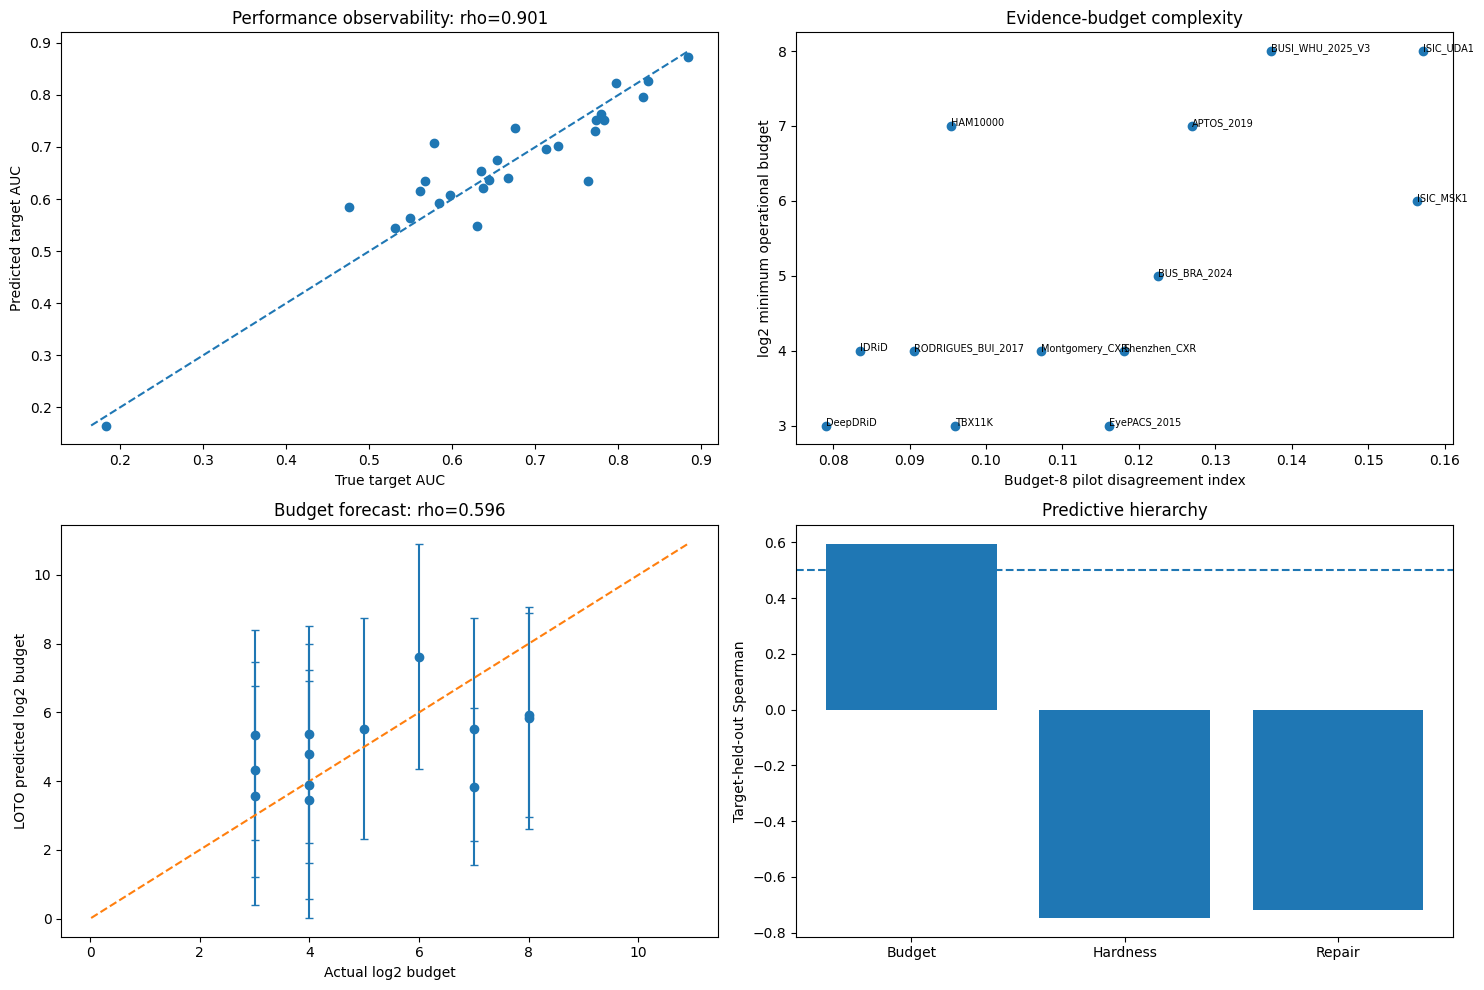

,gate,passed,observed
0,G1_parent_integrity,True,all parent/document hashes exact
1,G2_no_blind_touch,True,no blind path imported
2,G3_performance_mae,True,0.034905
3,G4_performance_rank,True,0.901099
4,G5_budget_rank,True,0.595656
5,G6_budget_baseline_gain,True,0.229369
6,G7_budget_exact_test,True,0.065422
7,G8_budget_interval_coverage,True,0.923077
8,G9_hardness_rank,False,-0.747253
9,G10_hardness_baseline_gain,False,-0.071966



========== STAGE T2-G COMPLETE ==========
Decision: SEAL_PERFORMANCE_AND_EVIDENCE_BUDGET_PREDICTABILITY_RETAIN_HARDNESS_AND_REPAIR_META_REGIMES_AS_UNIDENTIFIABLE
Performance observability supported: True
Evidence-budget predictability supported: True
Hardness meta-prediction supported: False
Repair-regime prediction supported: False
Blind assets touched: False
Blind outcomes accessed: False
Stage 12 authorised: False
Final record SHA256: 0ab2b7b61ab6e56a3e538fef449f51986ed398a0dbade3f9340e04381a75bb06


In [12]:
# @title T2-G-3. Gates, hierarchy decision, figures, sealed completion and manuscript insert
gates = pd.DataFrame([
    {"gate": "G1_parent_integrity", "passed": True, "observed": "all parent/document hashes exact"},
    {"gate": "G2_no_blind_touch", "passed": True, "observed": "no blind path imported"},
    {"gate": "G3_performance_mae", "passed": performance_median_mae <= 0.04, "observed": performance_median_mae},
    {"gate": "G4_performance_rank", "passed": performance_rank >= 0.85, "observed": performance_rank},
    {"gate": "G5_budget_rank", "passed": budget_metrics["spearman"] >= 0.50, "observed": budget_metrics["spearman"]},
    {"gate": "G6_budget_baseline_gain", "passed": budget_metrics["relative_mae_improvement"] >= 0.20, "observed": budget_metrics["relative_mae_improvement"]},
    {"gate": "G7_budget_exact_test", "passed": budget_metrics["exact_signflip_p_one_sided"] <= 0.10, "observed": budget_metrics["exact_signflip_p_one_sided"]},
    {"gate": "G8_budget_interval_coverage", "passed": budget_metrics["interval_coverage"] >= 0.85, "observed": budget_metrics["interval_coverage"]},
    {"gate": "G9_hardness_rank", "passed": hardness_metrics["spearman"] >= 0.50, "observed": hardness_metrics["spearman"]},
    {"gate": "G10_hardness_baseline_gain", "passed": hardness_metrics["relative_mae_improvement"] >= 0.15, "observed": hardness_metrics["relative_mae_improvement"]},
    {"gate": "G11_repair_rank", "passed": repair_metrics["spearman"] >= 0.50, "observed": repair_metrics["spearman"]},
    {"gate": "G12_repair_sign", "passed": repair_metrics["sign_accuracy"] >= 0.70, "observed": repair_metrics["sign_accuracy"]},
    {"gate": "G13_stage12_false", "passed": t3pf["stage12_authorised"] is False, "observed": t3pf["stage12_authorised"]},
])

gate_map = dict(zip(gates["gate"], gates["passed"]))
core_pass = all(gate_map[g] for g in ["G1_parent_integrity", "G2_no_blind_touch", "G3_performance_mae", "G4_performance_rank", "G13_stage12_false"])
budget_pass = all(gate_map[g] for g in ["G5_budget_rank", "G6_budget_baseline_gain", "G7_budget_exact_test", "G8_budget_interval_coverage"])
hardness_pass = all(gate_map[g] for g in ["G9_hardness_rank", "G10_hardness_baseline_gain"])
repair_pass = all(gate_map[g] for g in ["G11_repair_rank", "G12_repair_sign"])

if not core_pass:
    decision = "TERMINATE_PREDICTIVE_EXTENSION_CENTRAL_PERFORMANCE_OBSERVABILITY_NOT_REPRODUCED"
elif budget_pass and hardness_pass and repair_pass:
    decision = "SEAL_FULL_PREDICTIVE_OBSERVABILITY_HIERARCHY_AUTHORISE_BLIND_PREREGISTRATION_INSERT_ONLY"
elif budget_pass and hardness_pass:
    decision = "SEAL_PERFORMANCE_BUDGET_AND_HARDNESS_PREDICTABILITY_RETAIN_REPAIR_REGIME_AS_UNIDENTIFIABLE"
elif budget_pass:
    decision = "SEAL_PERFORMANCE_AND_EVIDENCE_BUDGET_PREDICTABILITY_RETAIN_HARDNESS_AND_REPAIR_META_REGIMES_AS_UNIDENTIFIABLE"
else:
    decision = "SEAL_PERFORMANCE_OBSERVABILITY_ONLY_REJECT_BROADER_META_PREDICTIVE_EXTENSION"

write_csv_once(P3 / "StageT2-G_Frozen_Gates_v0.1.csv", gates)

# Main figure
fig = plt.figure(figsize=(15, 10))
ax1 = fig.add_subplot(2, 2, 1)
ax1.scatter(edge_perf["true_auc"], edge_perf["predicted_auc"])
lo = min(edge_perf["true_auc"].min(), edge_perf["predicted_auc"].min())
hi = max(edge_perf["true_auc"].max(), edge_perf["predicted_auc"].max())
ax1.plot([lo, hi], [lo, hi], linestyle="--")
ax1.set_xlabel("True target AUC")
ax1.set_ylabel("Predicted target AUC")
ax1.set_title(f"Performance observability: rho={performance_rank:.3f}")

ax2 = fig.add_subplot(2, 2, 2)
ax2.scatter(budget_data["pilot_disagreement_index"], budget_data["log2_minimum_budget"])
for _, row in budget_data.iterrows():
    ax2.annotate(row["target"], (row["pilot_disagreement_index"], row["log2_minimum_budget"]), fontsize=7)
ax2.set_xlabel("Budget-8 pilot disagreement index")
ax2.set_ylabel("log2 minimum operational budget")
ax2.set_title("Evidence-budget complexity")

ax3 = fig.add_subplot(2, 2, 3)
ax3.errorbar(
    budget_pred["actual"], budget_pred["prediction"],
    yerr=budget_pred["interval_radius"], fmt="o", capsize=3
)
low = min(budget_pred["actual"].min(), budget_pred["interval_lower"].min())
high = max(budget_pred["actual"].max(), budget_pred["interval_upper"].max())
ax3.plot([low, high], [low, high], linestyle="--")
ax3.set_xlabel("Actual log2 budget")
ax3.set_ylabel("LOTO predicted log2 budget")
ax3.set_title(f"Budget forecast: rho={budget_metrics['spearman']:.3f}")

ax4 = fig.add_subplot(2, 2, 4)
x = np.arange(3)
vals = [
    budget_metrics["spearman"],
    hardness_metrics["spearman"],
    repair_metrics["spearman"],
]
ax4.bar(x, vals)
ax4.axhline(0.5, linestyle="--")
ax4.set_xticks(x, ["Budget", "Hardness", "Repair"])
ax4.set_ylabel("Target-held-out Spearman")
ax4.set_title("Predictive hierarchy")
fig.tight_layout()
figure_path = P4 / "StageT2-G_Predictive_Observability_Hierarchy_Main_Figure_v0.1.png"
fig.savefig(figure_path, dpi=220, bbox_inches="tight")
plt.show()

completion_payload = {
    "stage": "StageT2-G",
    "decision": decision,
    "parent_t2f_final_record_sha256": EXPECTED_T2F_RECORD,
    "parent_t3pf_activation_record_sha256": EXPECTED_T3PF_RECORD,
    "protocol_seal_sha256": protocol["protocol_seal_sha256"],
    "development_targets": int(t2f["target"].nunique()),
    "development_edges": int(t2f["edge_id"].nunique()),
    "performance_target_median_mae": performance_median_mae,
    "performance_edge_spearman": performance_rank,
    "budget_metrics": budget_metrics,
    "hardness_metrics": hardness_metrics,
    "repair_metrics": repair_metrics,
    "gates_passed": int(gates["passed"].sum()),
    "gates_total": int(len(gates)),
    "core_performance_supported": bool(core_pass),
    "evidence_budget_predictability_supported": bool(budget_pass),
    "hardness_meta_prediction_supported": bool(hardness_pass),
    "repair_regime_prediction_supported": bool(repair_pass),
    "blind_assets_touched": False,
    "blind_outcomes_accessed": False,
    "outcome_scoring_authorised": False,
    "stage12_authorised": False,
}
completion = seal(P4 / "StageT2-G_Complete_v0.1.json", completion_payload, "final_record_sha256")

summary = f"""# Stage T2-G result summary v0.1

- Decision: `{decision}`
- Performance target median MAE: `{performance_median_mae:.6f}`
- Performance edge Spearman: `{performance_rank:.6f}`
- Budget LOTO Spearman: `{budget_metrics['spearman']:.6f}`
- Budget relative MAE improvement: `{budget_metrics['relative_mae_improvement']:.2%}`
- Budget exact target sign-flip p: `{budget_metrics['exact_signflip_p_one_sided']:.6f}`
- Budget interval coverage: `{budget_metrics['interval_coverage']:.3f}`
- Hardness LOTO Spearman: `{hardness_metrics['spearman']:.6f}`
- Repair-gain LOTO Spearman: `{repair_metrics['spearman']:.6f}`
- Gates: `{int(gates['passed'].sum())}/{len(gates)}`
- Blind assets touched: `False`
- Blind outcomes accessed: `False`
- Final record SHA256: `{completion['final_record_sha256']}`
"""
write_once(P4 / "StageT2-G_Result_Summary_v0.1.md", summary)

manuscript = f"""# Predictive-observability development insert

Stage T2-G evaluated a three-level hierarchy on the same 13 development targets and did not access any locked-blind asset. The frozen RA-CB estimator reproduced target-performance observability with a target-level median absolute AUC error of {performance_median_mae:.6f} and 27-edge Spearman correlation of {performance_rank:.6f}. An eight-group pilot disagreement index was then used in nested leave-one-target-out regression to forecast the order of the minimum operational witness budget. The budget predictor achieved Spearman {budget_metrics['spearman']:.6f}, log2-budget MAE {budget_metrics['prediction_mae']:.6f}, and {budget_metrics['relative_mae_improvement']:.2%} improvement over a constant-budget baseline (exact target sign-flip p={budget_metrics['exact_signflip_p_one_sided']:.6f}). Outcome-free meta-prediction of final hardness and intervention gain achieved Spearman {hardness_metrics['spearman']:.6f} and {repair_metrics['spearman']:.6f}, respectively. These latter results are retained regardless of pass or failure and define whether cross-target regime prediction is supported or remains unidentifiable.
"""
write_once(P4 / "StageT2-G_Manuscript_Insert_v0.1.md", manuscript)

display(gates)
print("\n========== STAGE T2-G COMPLETE ==========")
print("Decision:", decision)
print("Performance observability supported:", core_pass)
print("Evidence-budget predictability supported:", budget_pass)
print("Hardness meta-prediction supported:", hardness_pass)
print("Repair-regime prediction supported:", repair_pass)
print("Blind assets touched:", False)
print("Blind outcomes accessed:", False)
print("Stage 12 authorised:", False)
print("Final record SHA256:", completion["final_record_sha256"])


## Interpretation boundary

- A pass in performance and budget prediction would support a broader predictive-auditing framework.
- A failure in hardness or repair prediction is not erased; it becomes an explicit identifiability boundary.
- All results remain development-only because the same 13 targets informed theory construction.
- The frozen T3 blind method is not changed by this notebook.
- No blind execution is authorised here.
